I0000 00:00:1775575400.620125  265924 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775575400.620520  265924 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775575400.645411  265924 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775575401.218444  265924 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.


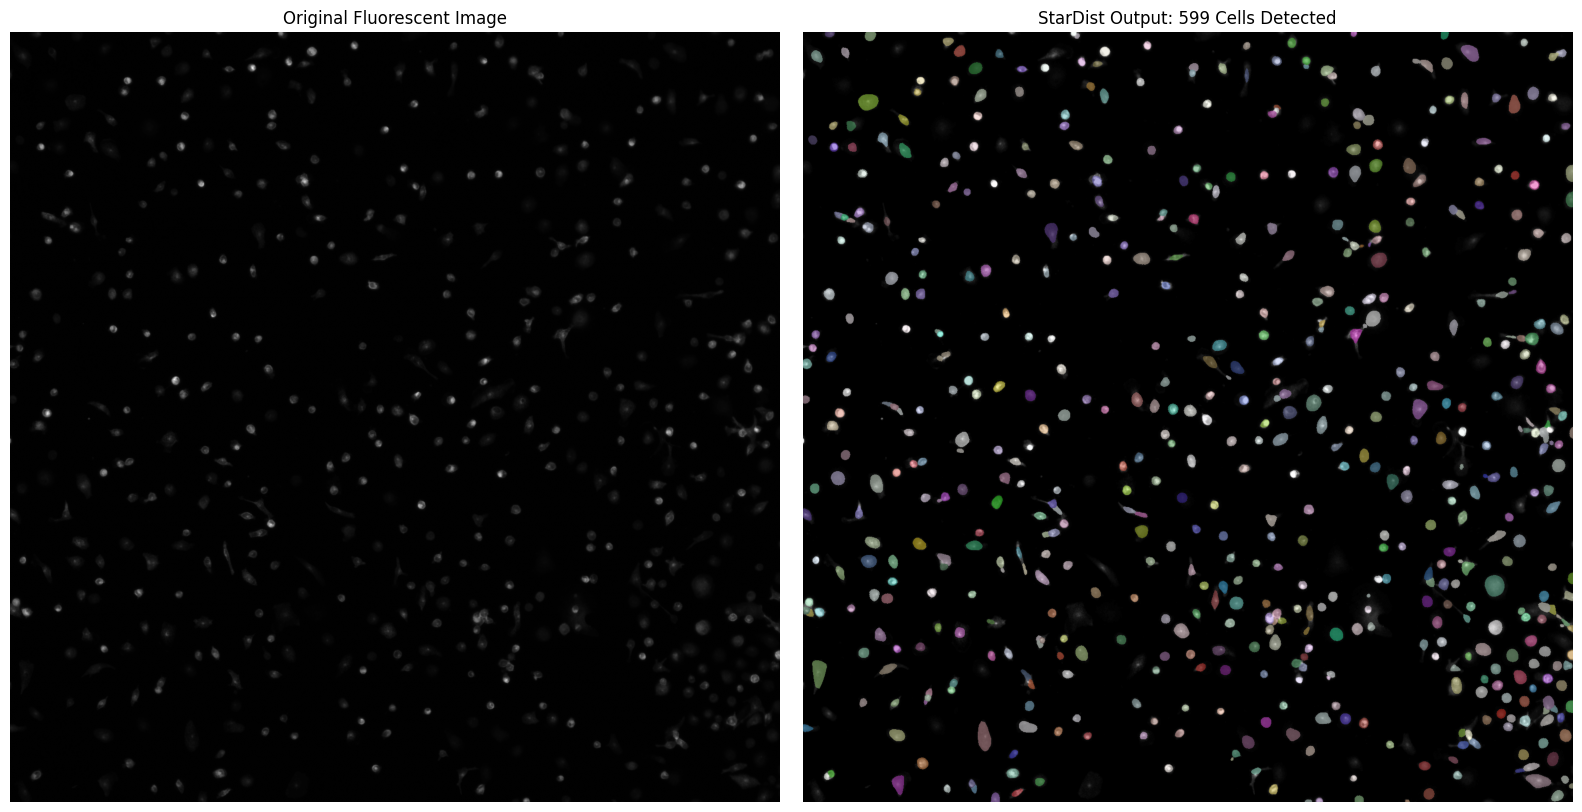

In [1]:
import matplotlib.pyplot as plt
import tifffile as tiff
import numpy as np
from csbdeep.utils import normalize
from stardist.models import StarDist2D
from stardist.plot import render_label

# 1. Load your image
image_path = "D47_T8CMNdermP6_CD200R_A488_CD206_A568_10x_RGB_Qi2 10x TRITC.tif"
img = tiff.imread(image_path)

# StarDist's 2D model expects a 2D grayscale array. 
# If your .tif loaded with an extra RGB/channel dimension, this safely flattens it:
if img.ndim == 3:
    img = img[:, :, 0]

# 2. Pull the pre-trained model explicitly built for fluorescent nuclei/cells
# It will download the weights automatically the first time you run this.
model = StarDist2D.from_pretrained('2D_versatile_fluo')

# 3. Normalize the image
# StarDist relies heavily on image normalization (typically 1st to 99.8th percentiles)
normalized_img = normalize(img, 1, 99.8, axis=(0,1))

# 4. Run the object detection
# 'labels' is an image mask where each cell gets a unique ID number
# 'details' is a dictionary containing the center coordinates of every detected dot
labels, details = model.predict_instances(normalized_img)

# 5. Plot the results side-by-side
plt.figure(figsize=(16, 8))

# Show original image
plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title("Original Fluorescent Image")

# Show StarDist predictions overlaid on the image
plt.subplot(1, 2, 2)
plt.imshow(render_label(labels, img=img))
plt.axis("off")
plt.title(f"StarDist Output: {len(details['points'])} Cells Detected")

plt.tight_layout()
plt.show()

Total cells analyzed: 599
Mean brightness: 28.95
Median brightness: 24.85


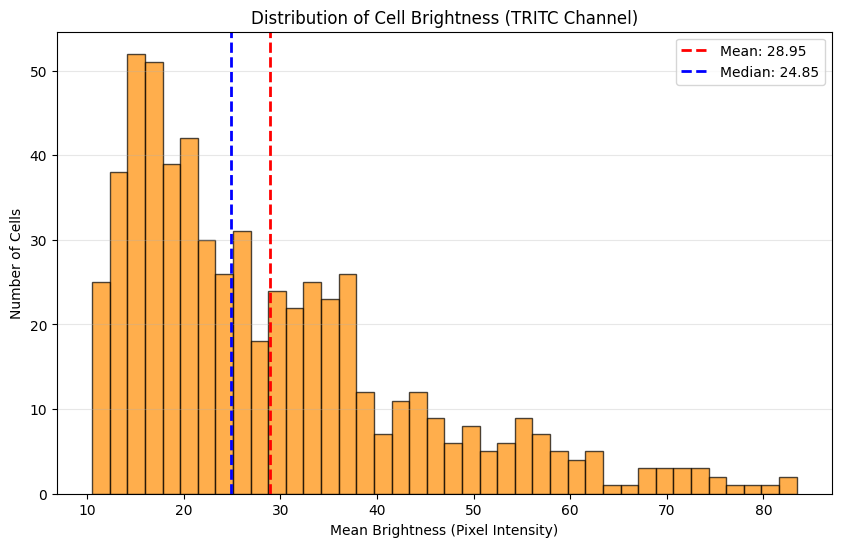

In [2]:
from skimage.measure import regionprops
import numpy as np

# 1. Extract properties for all detected regions
# We pass the StarDist labels and tell it to measure intensities from the original image
props = regionprops(labels, intensity_image=img)

# 2. Extract the mean brightness for every individual cell
mean_intensities = [cell.mean_intensity for cell in props]

# 3. Calculate your requested statistics
overall_mean = np.mean(mean_intensities)
overall_median = np.median(mean_intensities)

print(f"Total cells analyzed: {len(mean_intensities)}")
print(f"Mean brightness: {overall_mean:.2f}")
print(f"Median brightness: {overall_median:.2f}")

# 4. Plot the Distribution
plt.figure(figsize=(10, 6))

# Create a histogram of the intensities
plt.hist(mean_intensities, bins=40, color='darkorange', edgecolor='black', alpha=0.7)

# Add vertical lines for Mean and Median
plt.axvline(overall_mean, color='red', linestyle='dashed', linewidth=2, 
            label=f'Mean: {overall_mean:.2f}')
plt.axvline(overall_median, color='blue', linestyle='dashed', linewidth=2, 
            label=f'Median: {overall_median:.2f}')

plt.title('Distribution of Cell Brightness (TRITC Channel)')
plt.xlabel('Mean Brightness (Pixel Intensity)')
plt.ylabel('Number of Cells')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()